In [26]:
import os
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms, models
from tqdm.auto import tqdm

In [27]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Torch:", torch.__version__)

Device: cpu
Torch: 2.12.0+cpu


In [28]:
DATA_PATH = Path(r"C:\Users\ivanp\Desktop\MASTER\2oaño\TFM\archive\casia-webface")
assert DATA_PATH.exists(), f"No existe la ruta: {DATA_PATH}"
print(DATA_PATH)

C:\Users\ivanp\Desktop\MASTER\2oaño\TFM\archive\casia-webface


In [29]:
IMG_SIZE = 112
BATCH_SIZE = 64
EMBEDDING_DIM = 512
EPOCHS = 20
LR = 1e-4

# Para pruebas rápidas
DEBUG_MODE = True
DEBUG_MAX_TRAIN = 3000
DEBUG_MAX_GALLERY = 500
DEBUG_MAX_PROBE = 500

In [30]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Transformaciones solo para visualizar
vis_resize = transforms.Resize((IMG_SIZE, IMG_SIZE))
vis_flip = transforms.RandomHorizontalFlip(p=1.0)
to_tensor = transforms.ToTensor()

In [31]:
base_dataset = datasets.ImageFolder(DATA_PATH)

MAX_CLASSES = 1000  # número de identidades

# Filtrar clases
selected_classes = set(range(MAX_CLASSES))

filtered_samples = [
    (path, label)
    for path, label in base_dataset.samples
    if label in selected_classes
]

# Actualizamos dataset
base_dataset.samples = filtered_samples
base_dataset.targets = [label for _, label in filtered_samples]
base_dataset.classes = base_dataset.classes[:MAX_CLASSES]

class_counts = {}
for _, label in base_dataset.samples:
    class_counts[label] = class_counts.get(label, 0) + 1

base_dataset.samples = [
    (path, label)
    for path, label in base_dataset.samples
    if class_counts[label] >= 5
]

base_dataset.targets = [label for _, label in base_dataset.samples]

print("Número de clases usadas:", len(base_dataset.classes))
print("Número de imágenes:", len(base_dataset))

Número de clases usadas: 1000
Número de imágenes: 82425


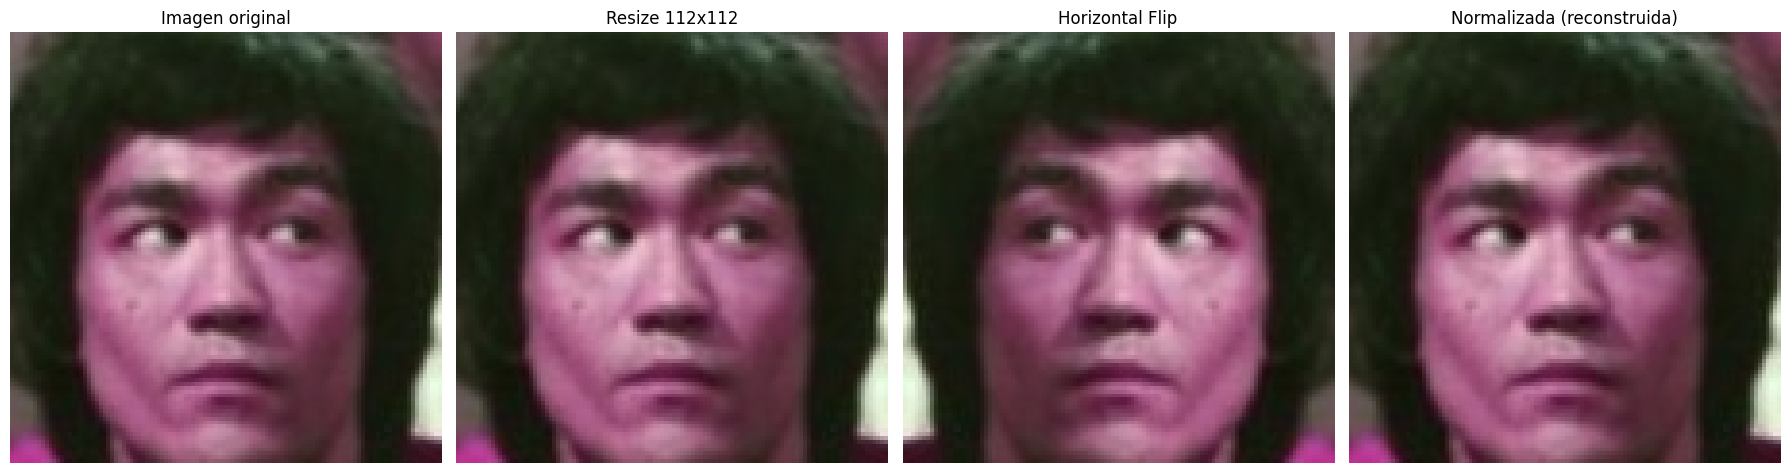

In [32]:
def denormalize(tensor_img):
    x = tensor_img.clone().cpu()
    x = x * 0.5 + 0.5
    return torch.clamp(x, 0, 1)

sample_path, sample_label = base_dataset.samples[0]
img = Image.open(sample_path).convert("RGB")

img_resized = vis_resize(img)
img_flipped = vis_flip(img_resized)
img_normalized = eval_transform(img)
img_normalized_vis = denormalize(img_normalized)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(img_resized)
axes[1].set_title(f"Resize {IMG_SIZE}x{IMG_SIZE}")
axes[1].axis("off")

axes[2].imshow(img_flipped)
axes[2].set_title("Horizontal Flip")
axes[2].axis("off")

axes[3].imshow(np.transpose(img_normalized_vis.numpy(), (1, 2, 0)))
axes[3].set_title("Normalizada (reconstruida)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

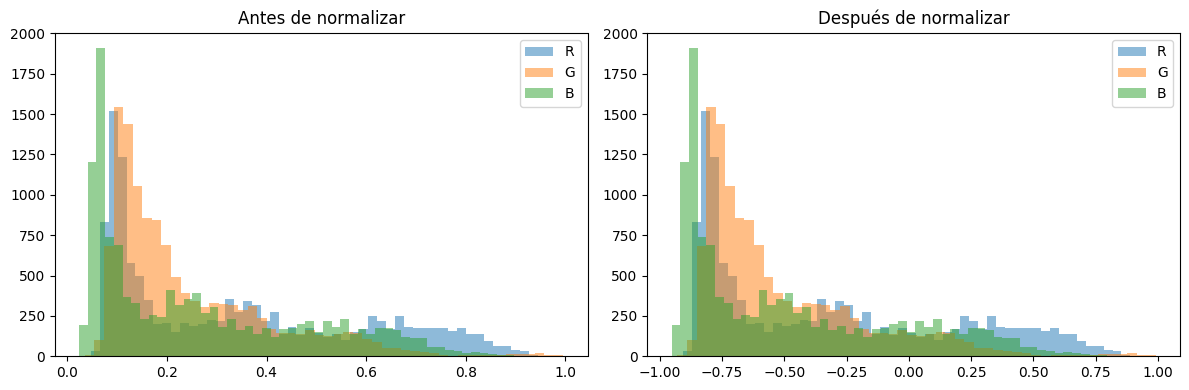

In [33]:
orig_np = np.array(img_resized).astype(np.float32) / 255.0
norm_np = np.transpose(img_normalized.numpy(), (1, 2, 0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(orig_np[..., 0].ravel(), bins=50, alpha=0.5, label="R")
axes[0].hist(orig_np[..., 1].ravel(), bins=50, alpha=0.5, label="G")
axes[0].hist(orig_np[..., 2].ravel(), bins=50, alpha=0.5, label="B")
axes[0].set_title("Antes de normalizar")
axes[0].legend()

axes[1].hist(norm_np[..., 0].ravel(), bins=50, alpha=0.5, label="R")
axes[1].hist(norm_np[..., 1].ravel(), bins=50, alpha=0.5, label="G")
axes[1].hist(norm_np[..., 2].ravel(), bins=50, alpha=0.5, label="B")
axes[1].set_title("Después de normalizar")
axes[1].legend()

plt.tight_layout()
plt.show()

In [34]:
class_to_indices = defaultdict(list)

for idx, (_, label) in enumerate(base_dataset.samples):
    class_to_indices[label].append(idx)

train_indices = []
gallery_indices = []
probe_indices = []

for cls, indices in class_to_indices.items():
    random.shuffle(indices)
    if len(indices) >= 5:
        gallery_indices.extend(indices[:3])
        probe_indices.append(indices[3])
        train_indices.extend(indices[4:])
    elif len(indices) == 2:
        gallery_indices.append(indices[0])
        probe_indices.append(indices[1])
    else:
        train_indices.extend(indices)

print("Train:", len(train_indices))
print("Gallery:", len(gallery_indices))
print("Probe:", len(probe_indices))

Train: 78425
Gallery: 3000
Probe: 1000


In [35]:
if DEBUG_MODE:
    train_indices = random.sample(train_indices, min(DEBUG_MAX_TRAIN, len(train_indices)))
    gallery_indices = random.sample(gallery_indices, min(DEBUG_MAX_GALLERY, len(gallery_indices)))
    probe_indices = random.sample(probe_indices, min(DEBUG_MAX_PROBE, len(probe_indices)))

    print("DEBUG activado")
    print("Train:", len(train_indices))
    print("Gallery:", len(gallery_indices))
    print("Probe:", len(probe_indices))

DEBUG activado
Train: 3000
Gallery: 500
Probe: 500


In [36]:
train_dataset_full = datasets.ImageFolder(DATA_PATH, transform=train_transform)
eval_dataset_full = datasets.ImageFolder(DATA_PATH, transform=eval_transform)

train_dataset = Subset(train_dataset_full, train_indices)
gallery_dataset = Subset(eval_dataset_full, gallery_indices)
probe_dataset = Subset(eval_dataset_full, probe_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
gallery_loader = DataLoader(gallery_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
probe_loader = DataLoader(probe_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [37]:
class ResNet50Backbone(nn.Module):
    def __init__(self, embedding_dim=512, pretrained=True):
        super().__init__()

        if pretrained:
            weights = models.ResNet50_Weights.IMAGENET1K_V2
        else:
            weights = None

        model = models.resnet50(weights=weights)
        self.features = nn.Sequential(*list(model.children())[:-1])
        self.embedding = nn.Linear(2048, embedding_dim)
        self.bn = nn.BatchNorm1d(embedding_dim)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.embedding(x)
        x = self.bn(x)
        x = F.normalize(x, p=2, dim=1)
        return x

In [38]:
class CosFaceHead(nn.Module):
    def __init__(self, in_features, out_features, s=64.0, m=0.35):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.s = s
        self.m = m

    def forward(self, x, labels):
        cosine = F.linear(F.normalize(x), F.normalize(self.weight))

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        logits = cosine - one_hot * self.m
        logits = logits * self.s
        return logits

In [39]:
class ArcFaceHead(nn.Module):
    def __init__(self, in_features, out_features, s=64.0, m=0.50):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.s = s
        self.m = m

    def forward(self, x, labels):
        cosine = F.linear(F.normalize(x), F.normalize(self.weight))
        cosine = torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7)

        theta = torch.acos(cosine)
        target_logit = torch.cos(theta + self.m)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        logits = cosine * (1 - one_hot) + target_logit * one_hot
        logits = logits * self.s
        return logits

In [40]:
def train_model(backbone, head, train_loader, epochs=5, lr=1e-4):
    backbone = backbone.to(device)
    head = head.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        list(backbone.parameters()) + list(head.parameters()),
        lr=lr
    )

    history = {"loss": []}

    for epoch in range(epochs):
        backbone.train()
        head.train()
        running_loss = 0.0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            feats = backbone(imgs)
            logits = head(feats, labels)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        history["loss"].append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

    return backbone, head, history


In [41]:
backbone_cos = ResNet50Backbone(embedding_dim=EMBEDDING_DIM, pretrained=True)
head_cos = CosFaceHead(
    in_features=EMBEDDING_DIM,
    out_features=len(base_dataset.classes),
    s=64.0,
    m=0.35
)

backbone_cos, head_cos, hist_cos = train_model(
    backbone_cos,
    head_cos,
    train_loader,
    epochs=EPOCHS,
    lr=LR
)

Epoch 1/20 - Loss: 32.6752
Epoch 2/20 - Loss: 27.3568
Epoch 3/20 - Loss: 23.4653
Epoch 4/20 - Loss: 19.8591
Epoch 5/20 - Loss: 16.4016
Epoch 6/20 - Loss: 13.3540
Epoch 7/20 - Loss: 10.4435
Epoch 8/20 - Loss: 7.4885
Epoch 9/20 - Loss: 5.0786
Epoch 10/20 - Loss: 3.3925
Epoch 11/20 - Loss: 2.1722
Epoch 12/20 - Loss: 1.1759
Epoch 13/20 - Loss: 0.7490
Epoch 14/20 - Loss: 0.5139
Epoch 15/20 - Loss: 0.3527
Epoch 16/20 - Loss: 0.1991
Epoch 17/20 - Loss: 0.1151
Epoch 18/20 - Loss: 0.0842
Epoch 19/20 - Loss: 0.0601
Epoch 20/20 - Loss: 0.0450


In [42]:
backbone_arc = ResNet50Backbone(embedding_dim=EMBEDDING_DIM, pretrained=True)
head_arc = ArcFaceHead(
    in_features=EMBEDDING_DIM,
    out_features=len(base_dataset.classes),
    s=64.0,
    m=0.50
)

backbone_arc, head_arc, hist_arc = train_model(
    backbone_arc,
    head_arc,
    train_loader,
    epochs=EPOCHS,
    lr=LR
)

Epoch 1/20 - Loss: 40.9131
Epoch 2/20 - Loss: 36.2072
Epoch 3/20 - Loss: 32.5539
Epoch 4/20 - Loss: 28.9950
Epoch 5/20 - Loss: 25.4038
Epoch 6/20 - Loss: 22.1228
Epoch 7/20 - Loss: 18.5601
Epoch 8/20 - Loss: 15.2647
Epoch 9/20 - Loss: 11.9828
Epoch 10/20 - Loss: 9.1624
Epoch 11/20 - Loss: 7.0561
Epoch 12/20 - Loss: 4.7235
Epoch 13/20 - Loss: 3.2627
Epoch 14/20 - Loss: 1.9869
Epoch 15/20 - Loss: 1.1652
Epoch 16/20 - Loss: 0.7081
Epoch 17/20 - Loss: 0.4758
Epoch 18/20 - Loss: 0.2989
Epoch 19/20 - Loss: 0.2075
Epoch 20/20 - Loss: 0.1337


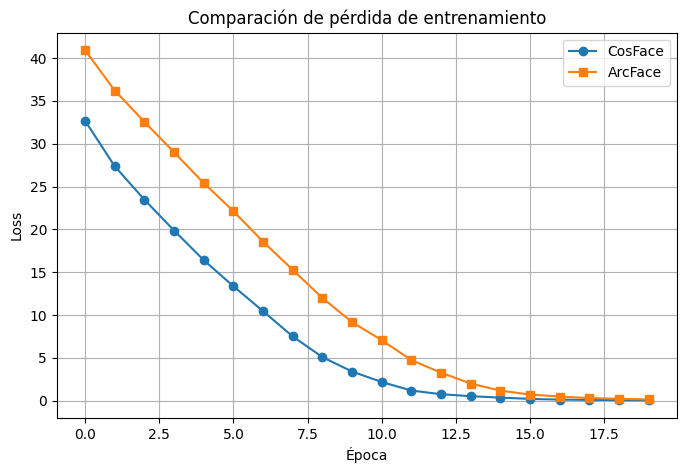

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(hist_cos["loss"], marker="o", label="CosFace")
plt.plot(hist_arc["loss"], marker="s", label="ArcFace")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Comparación de pérdida de entrenamiento")
plt.grid(True)
plt.legend()
plt.show()

In [44]:
def extract_embeddings(backbone, loader):
    backbone.eval()
    all_feats = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Extrayendo embeddings"):
            imgs = imgs.to(device)
            feats = backbone(imgs).cpu()
            all_feats.append(feats)
            all_labels.append(labels)

    feats = torch.cat(all_feats, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return feats, labels

In [45]:
def compute_similarity_matrix(probe_feats, gallery_feats):
    return probe_feats @ gallery_feats.T  # embeddings normalizados -> coseno

def topk_accuracy(sim_matrix, probe_labels, gallery_labels, k=1):
    topk_idx = torch.topk(sim_matrix, k=k, dim=1).indices
    preds = gallery_labels[topk_idx]
    correct = (preds == probe_labels.unsqueeze(1)).any(dim=1).float().mean().item()
    return correct

def cmc_curve(sim_matrix, probe_labels, gallery_labels, max_k=20):
    cmc = []
    for k in range(1, max_k + 1):
        cmc.append(topk_accuracy(sim_matrix, probe_labels, gallery_labels, k=k))
    return cmc

In [46]:
gallery_feats_cos, gallery_labels = extract_embeddings(backbone_cos, gallery_loader)
probe_feats_cos, probe_labels = extract_embeddings(backbone_cos, probe_loader)

sim_cos = compute_similarity_matrix(probe_feats_cos, gallery_feats_cos)

top1_cos = topk_accuracy(sim_cos, probe_labels, gallery_labels, k=1)
top5_cos = topk_accuracy(sim_cos, probe_labels, gallery_labels, k=5)
cmc_cos = cmc_curve(sim_cos, probe_labels, gallery_labels, max_k=20)

print("CosFace Top-1:", top1_cos)
print("CosFace Top-5:", top5_cos)

Extrayendo embeddings: 100%|██████████| 8/8 [00:22<00:00,  2.83s/it]


CosFace Top-1: 0.014000000432133675
CosFace Top-5: 0.04800000041723251


In [47]:
gallery_feats_arc, gallery_labels = extract_embeddings(backbone_arc, gallery_loader)
probe_feats_arc, probe_labels = extract_embeddings(backbone_arc, probe_loader)

sim_arc = compute_similarity_matrix(probe_feats_arc, gallery_feats_arc)

top1_arc = topk_accuracy(sim_arc, probe_labels, gallery_labels, k=1)
top5_arc = topk_accuracy(sim_arc, probe_labels, gallery_labels, k=5)
cmc_arc = cmc_curve(sim_arc, probe_labels, gallery_labels, max_k=20)

print("ArcFace Top-1:", top1_arc)
print("ArcFace Top-5:", top5_arc)

Extrayendo embeddings: 100%|██████████| 8/8 [00:22<00:00,  2.81s/it]


ArcFace Top-1: 0.024000000208616257
ArcFace Top-5: 0.05400000140070915


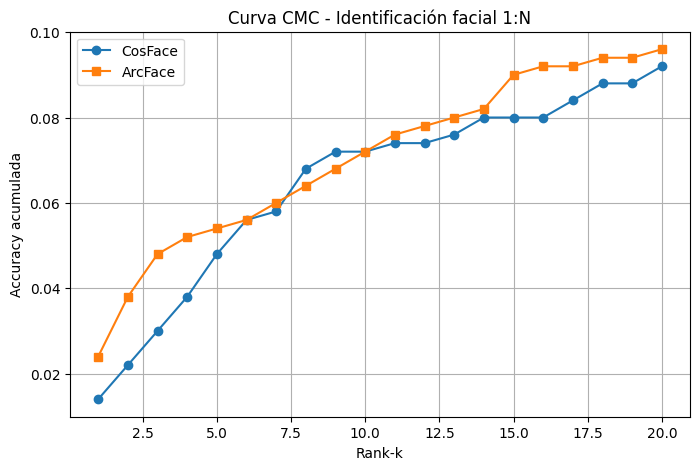

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cmc_cos)+1), cmc_cos, marker="o", label="CosFace")
plt.plot(range(1, len(cmc_arc)+1), cmc_arc, marker="s", label="ArcFace")
plt.xlabel("Rank-k")
plt.ylabel("Accuracy acumulada")
plt.title("Curva CMC - Identificación facial 1:N")
plt.grid(True)
plt.legend()
plt.show()

In [49]:
print(f"CosFace -> Top-1: {top1_cos:.4f} | Top-5: {top5_cos:.4f}")
print(f"ArcFace -> Top-1: {top1_arc:.4f} | Top-5: {top5_arc:.4f}")

CosFace -> Top-1: 0.0140 | Top-5: 0.0480
ArcFace -> Top-1: 0.0240 | Top-5: 0.0540
